In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the dataset
# Replace 'your_dataset_url' with the actual URL or file path
url = 'https://archive.ics.uci.edu/dataset/109/wine'

# Exploratory Data Analysis (EDA)
# Explore the dataset's structure and summary statistics

wine = fetch_ucirepo(id=109)

# Data and labels
X = wine.data.features
y = wine.data.targets

print("Wine Metadata: \n")
print(wine.metadata)
print("\nWine Summary Statistics: \n")
print(X.describe())
print("\nWine Dataset Structure: \n")
print(X.info())

Wine Metadata: 

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7

In [4]:
print(X.columns)

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline'],
      dtype='object')


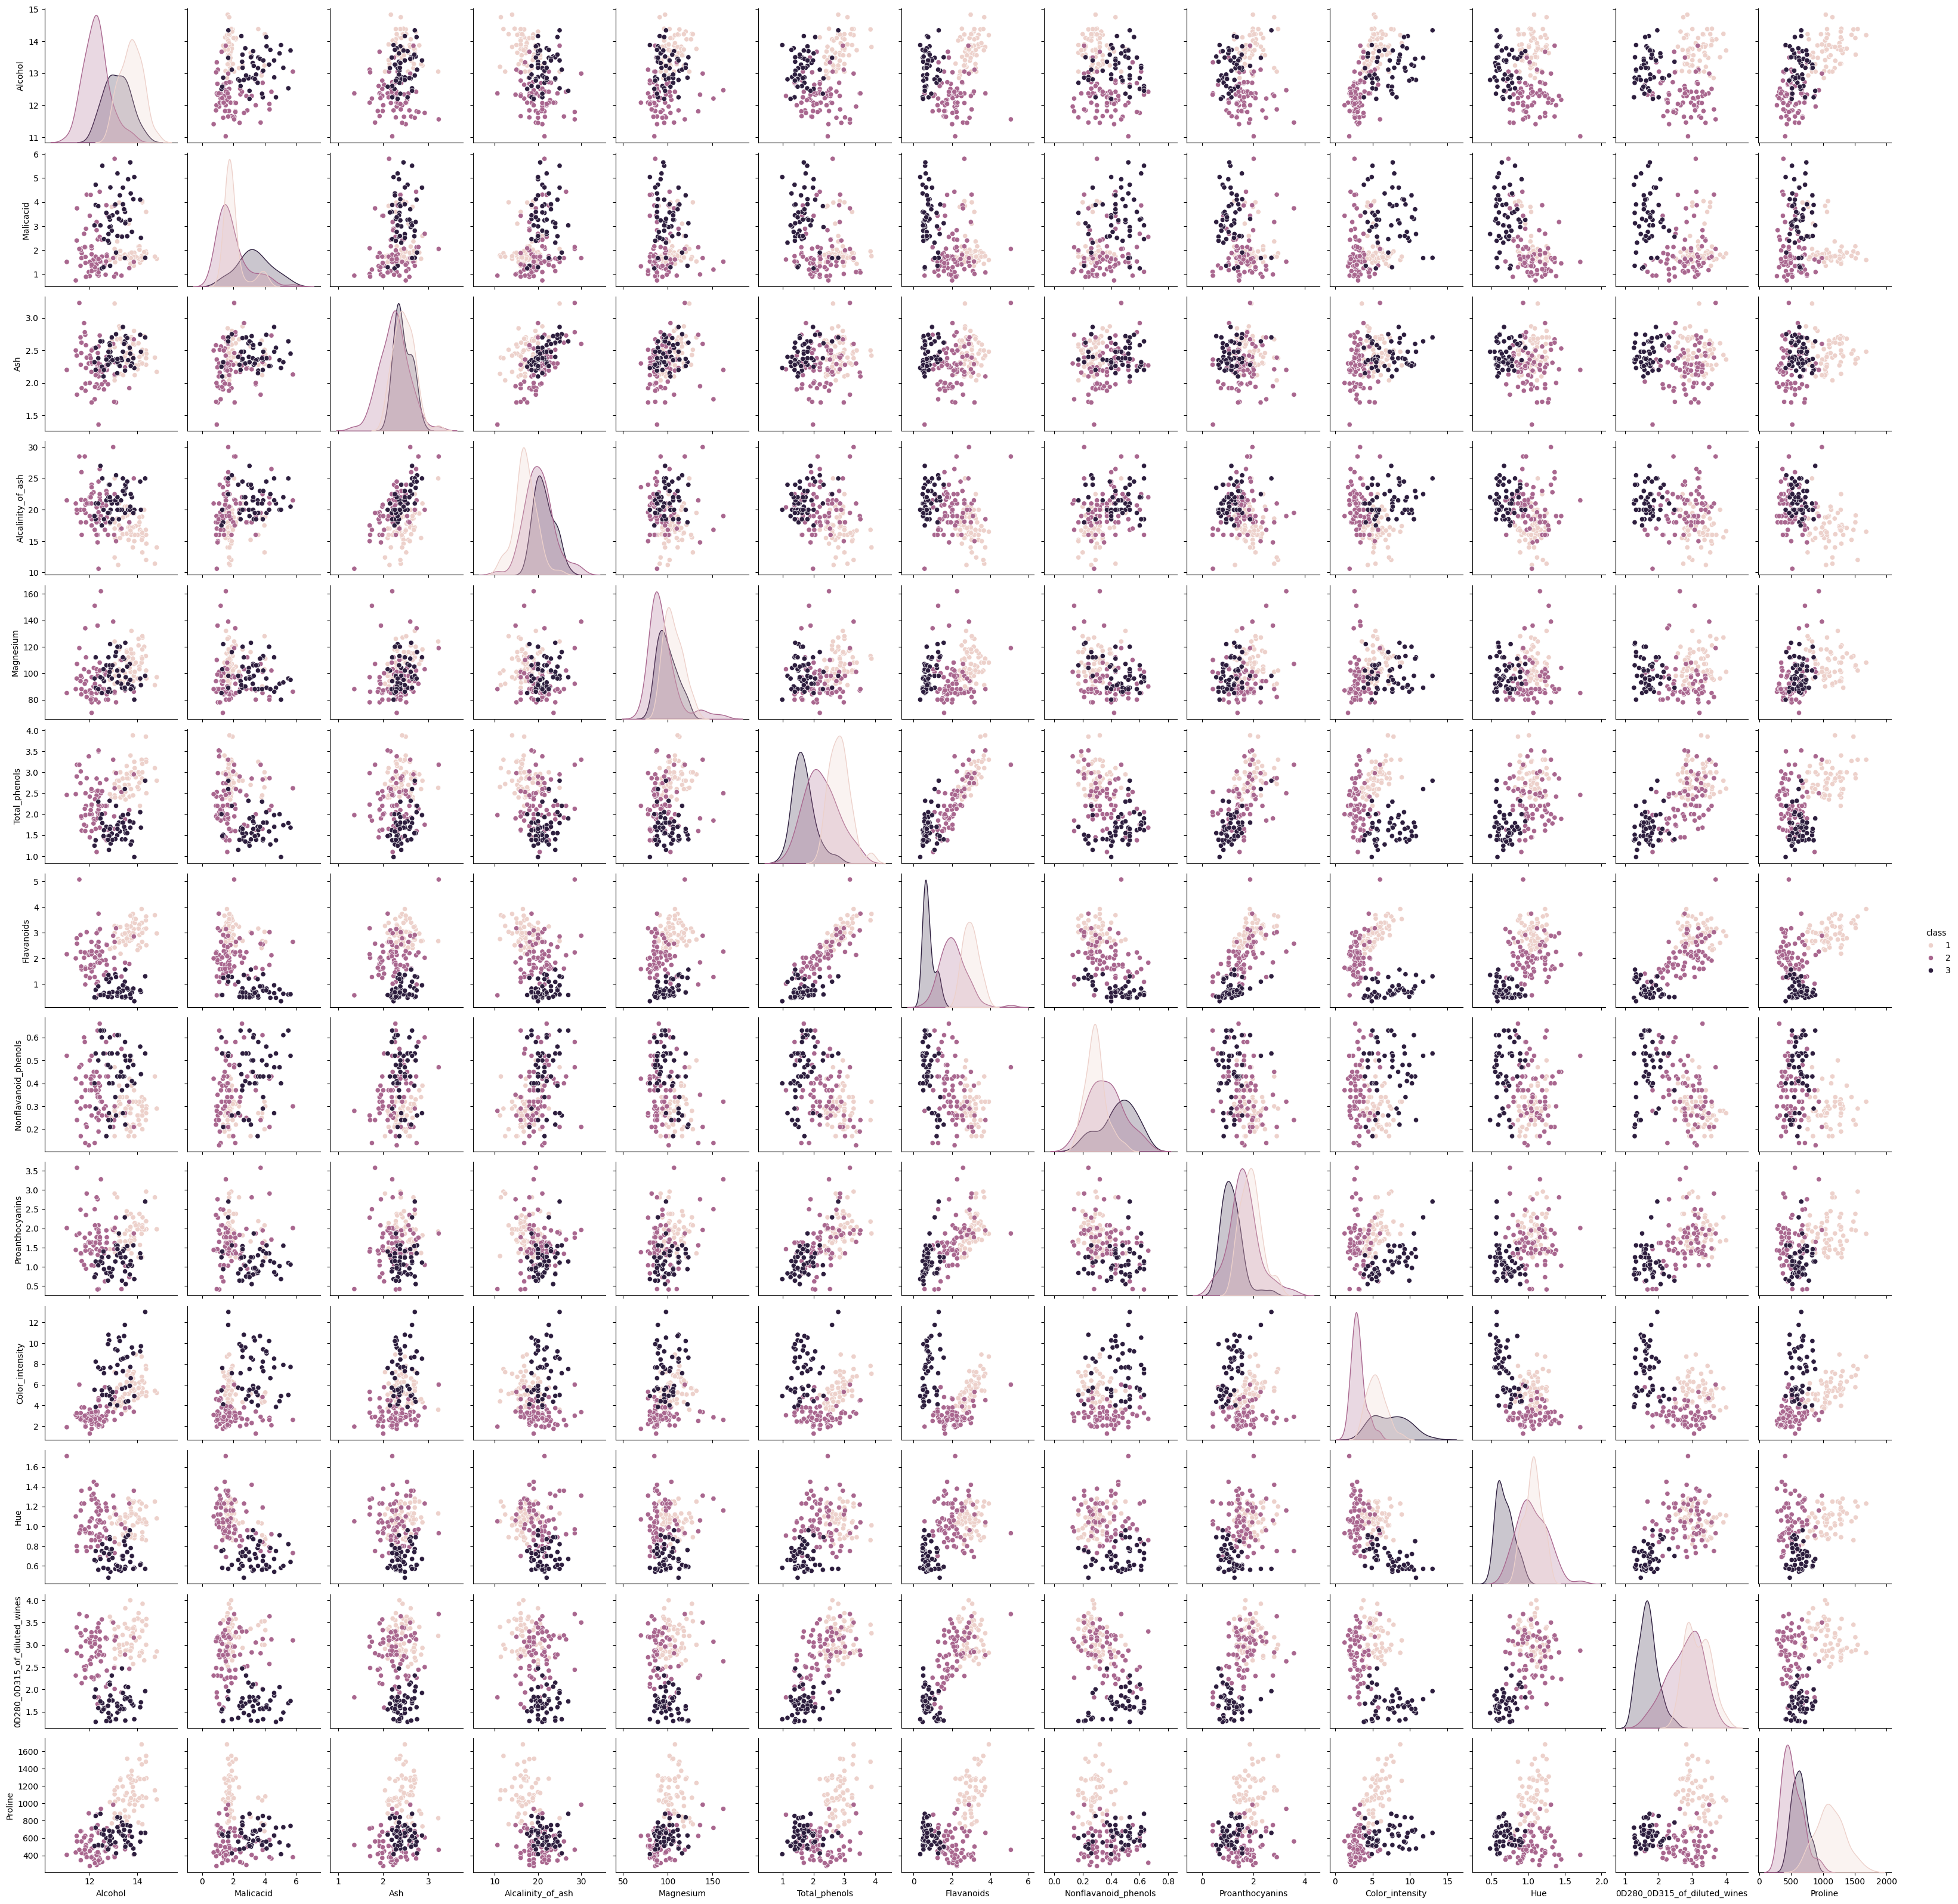

In [ ]:
sns.pairplot(pd.concat([X, y], axis=1), hue='class')
plt.show()

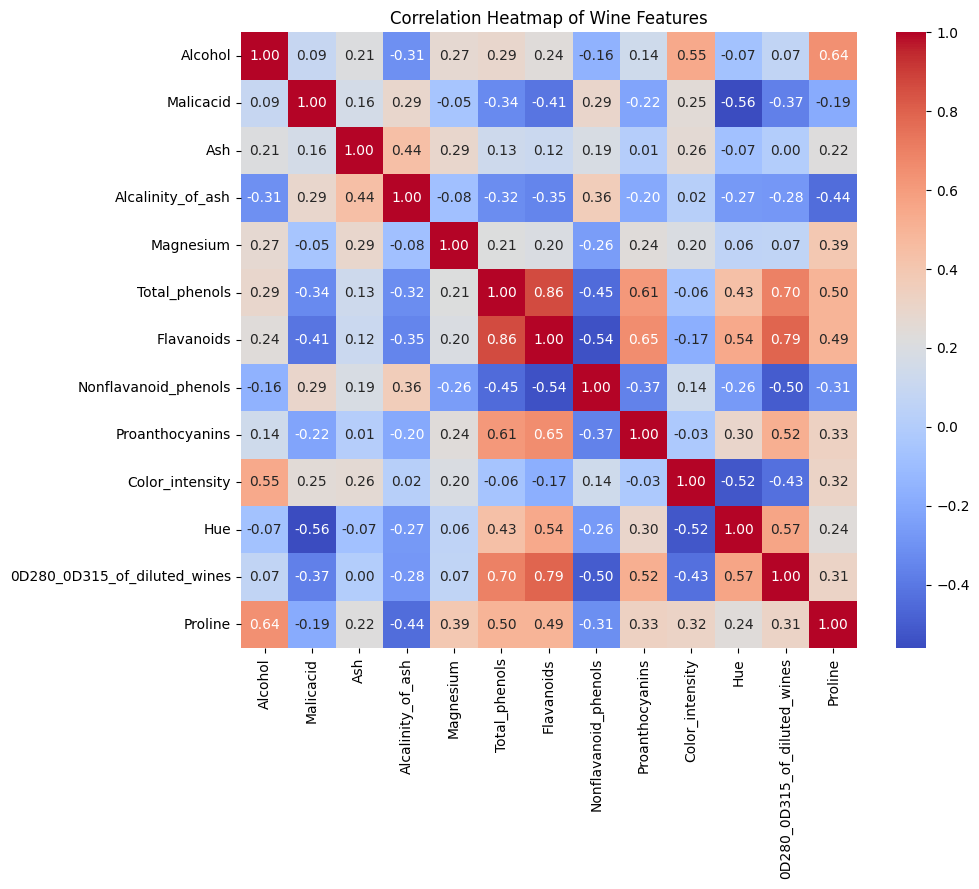

In [10]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Wine Features')
plt.show()



In [1]:
# Hypothesis Formulation
# Formulate at least two hypotheses based on what you observe in the visuals

print("Higher alcohol content is associated with higher proline levels in wine.")
print("Higher levels of malic acid are associated with a lower hue intensity in the samples.")


Higher alcohol content is associated with higher proline levels in wine.
Higher levels of malic acid are associated with a lower hue intensity in the samples.


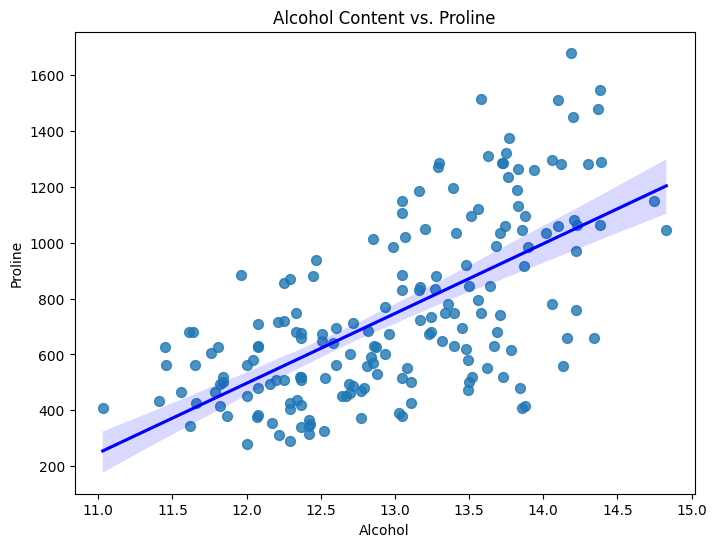

In [8]:
# Hypothesis Testing
# Test the formulated hypotheses using statistical tests or visualizations
plt.figure(figsize=(8, 6))
sns.regplot(x='Alcohol', y='Proline', data=X, scatter_kws={'s': 50}, line_kws={'color': 'blue'})
plt.title('Alcohol Content vs. Proline')
plt.xlabel('Alcohol')
plt.ylabel('Proline')
plt.show()


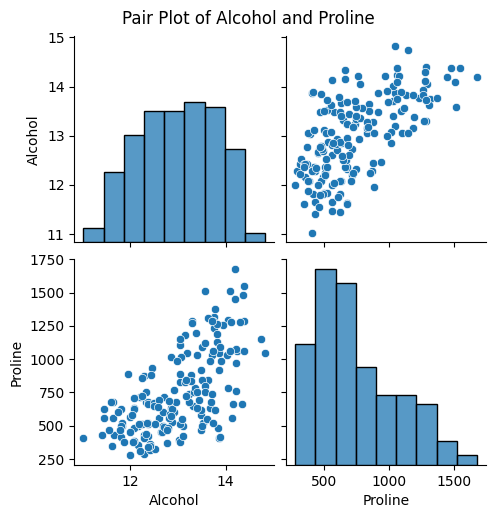

In [18]:
pair_plot = sns.pairplot(X[['Alcohol', 'Proline']])
pair_plot.fig.suptitle('Pair Plot of Alcohol and Proline', y=1.02)
plt.show()

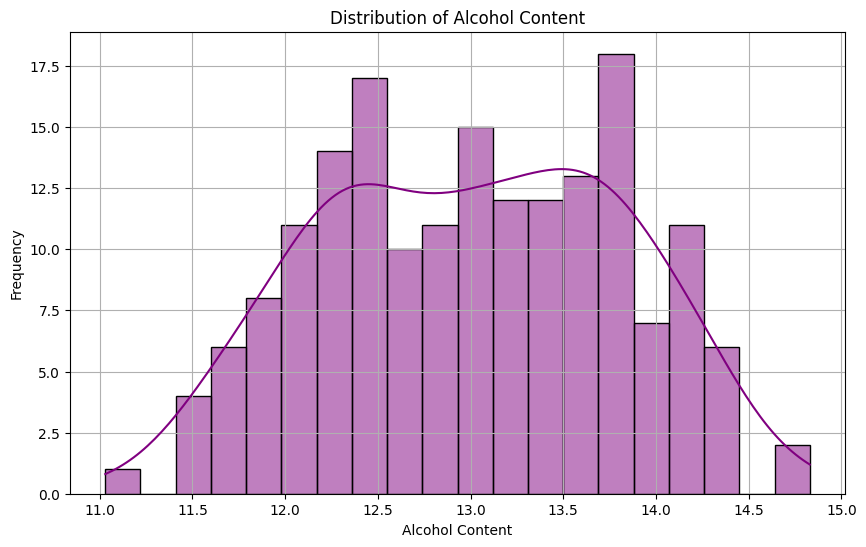

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(X['Alcohol'], bins=20, kde=True, color='purple')
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol Content')
plt.ylabel('Frequency')
plt.grid()
plt.show()

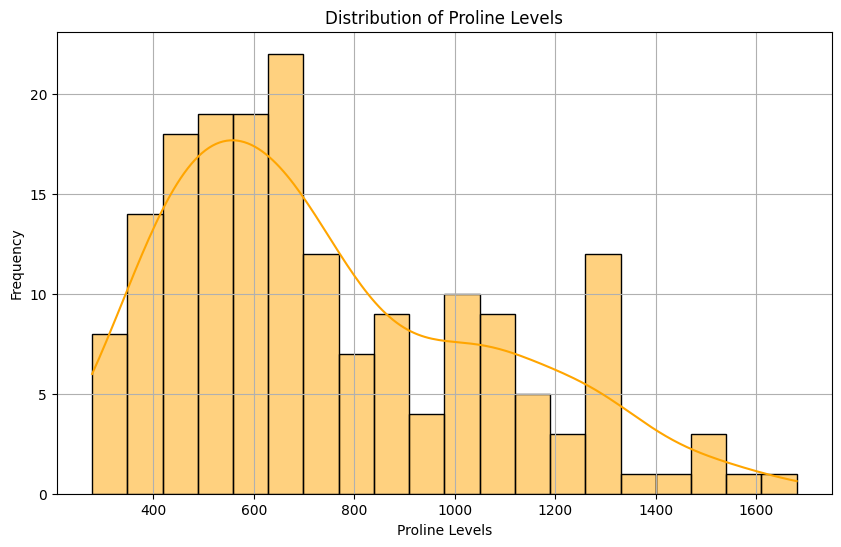

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(X['Proline'], bins=20, kde=True, color='orange')
plt.title('Distribution of Proline Levels')
plt.xlabel('Proline Levels')
plt.ylabel('Frequency')
plt.grid()
plt.show()


###Hypothesis 2

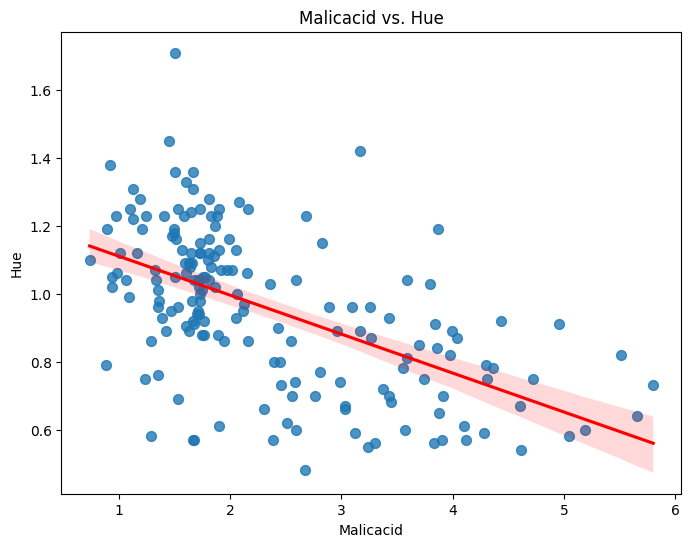

In [19]:
plt.figure(figsize=(8, 6))
sns.regplot(x='Malicacid', y='Hue', data=X, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Malicacid vs. Hue')
plt.xlabel('Malicacid')
plt.ylabel('Hue')
plt.show()


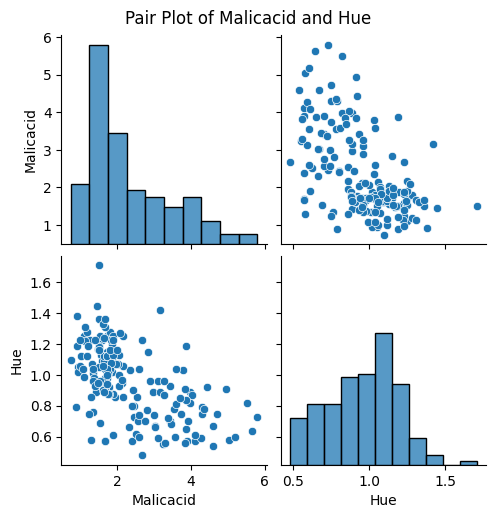

In [20]:
pair_plot = sns.pairplot(X[['Malicacid', 'Hue']])
pair_plot.fig.suptitle('Pair Plot of Malicacid and Hue', y=1.02)
plt.show()

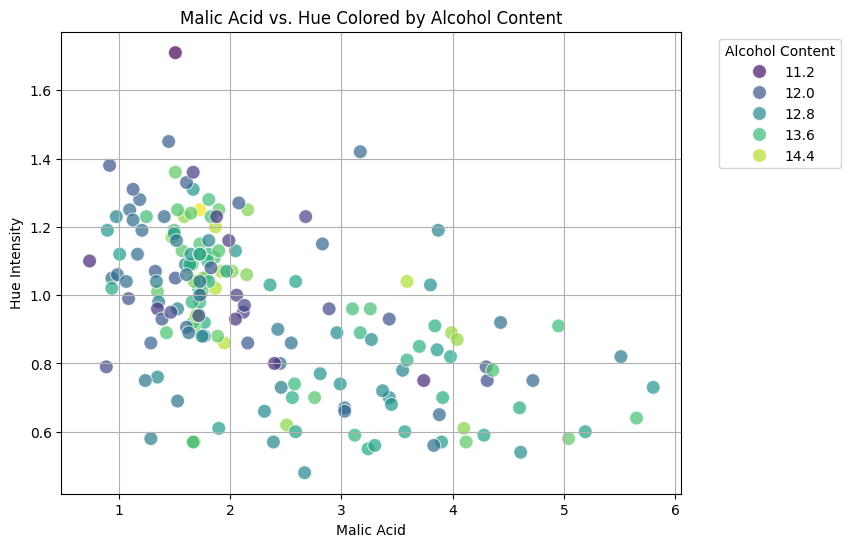

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Malicacid', y='Hue', hue='Alcohol', palette='viridis', data=X, alpha=0.7, s=100)
plt.title('Malic Acid vs. Hue Colored by Alcohol Content')
plt.xlabel('Malic Acid')
plt.ylabel('Hue Intensity')
plt.legend(title='Alcohol Content', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

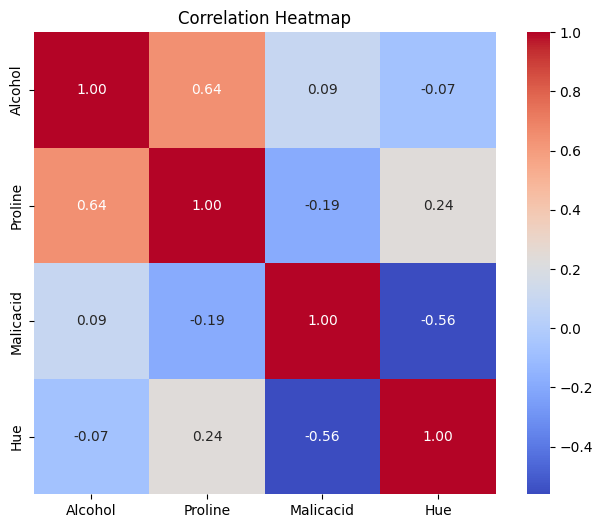

In [7]:
plt.figure(figsize=(8, 6))
correlation_matrix = X[['Alcohol', 'Proline', 'Malicacid', 'Hue']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar=True)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
# Documentation and Reporting
# Document the entire analysis process, including code and explanations
# Summarize key findings in a clear and concise report
print("EDA Documentation:")
print("After loading the dataset, I analyzed some of the key characteristics by printing the Wine summary statistics, structure, and metadata. \n" +
      "This gave me insight into the overall structure of the dataset. After analyzing the some of the key metrics, I decided to compare each of the \n" +
      "columns agains one another. While this took a while for the plots to load, I received a numerous amount of plots that I could analyze. It was a \n" +
      "bit difficult to identify any trends since the plots looked all the same. This was when I decided to do a correlation heatmap. This visualization was \n" +
      "much easier to find any relationships between the columns. For example some variables that have a postive correlation was Flavanoids and Total_Phenols, \n" +
      "Proline and Alochol, Flavanoids and 0D280_0D315_of_diluted_wines. Some variables that have a negative correlation are Hue and Malicaci, Hue and Color Intensity, \n" +
      "Alcalinity_of_ash and Proline.")

print("\n")

print("Analysis/Key Findings")
print("After analyzing the inital pots, I decided to focus my hypothesis on 1. Higher alcohol content is associated with higher proline levels in wine. \n" +
      "2. Higher levels of malic acid are associated with a lower hue intensity in the samples. I chose to focus on these variables because they are more widely \n" +
      "known to most people who don't know too much about wine sampling. After plotting a regression plot, I was able to verify both hypotheses. Both indicated \n" +
      "a clear positive or negative direction, which is what we had expected. Additionally, the pair plot gave us further insight into the variables Alcohol Content \n" +
      "and Proline indicating a positive trend and a negative trend between Malic Acid and Hue. The histograms showed us that for alochol content, the distribution \n" +
      "is roughly normally distributed, so one can find a middle ground that fits for most people. Proline, on the other hand, shows a right skewed distribution \n" +
      "meaning most people prefer a lower Proline content. Finally, in our scatter plot between Malic Acid and Hue, there is a clear cluster of points on the lower \n" +
      "side of Malic Acid, with an indication of Hue Intensity decreasing as Malic Acid increases. Again, this shows the negative correlation between the two points.")

print("\n")

print("What I learned:")
print("Something that I learned while performing EDA on this report was to focus on on the simple metrics. It was only after analyzing the structure of the data, was \n" +
      "I able to choose which variables to focus on. I learned that creating a pairplot with all the variables isn't necessarily a great idea initially since it is difficult \n" +
      "to extract any meaningful insights. Instead something like a correlation heatmap does a better job at telling me which variables to focus on. I also learned \n" +
      "to choose variables based on my audience. Since this report is mostly for other students, I can't expect most to be wine experts, which is why I chose the \n" +
      "more basic variables. However, if I were to be talking to a group of wine experts, it would be much more beneficial to look into other variables/factors that \n" +
      "impact the wine quality.")

EDA Documentation:
After loading the dataset, I analyzed some of the key characteristics by printing the Wine summary statistics, structure, and metadata. 
This gave me insight into the overall structure of the dataset. After analyzing the some of the key metrics, I decided to compare each of the 
columns agains one another. While this took a while for the plots to load, I received a numerous amount of plots that I could analyze. It was a 
bit difficult to identify any trends since the plots looked all the same. This was when I decided to do a correlation heatmap. This visualization was 
much easier to find any relationships between the columns. For example some variables that have a postive correlation was Flavanoids and Total_Phenols, 
Proline and Alochol, Flavanoids and 0D280_0D315_of_diluted_wines. Some variables that have a negative correlation are Hue and Malicaci, Hue and Color Intensity, 
Alcalinity_of_ash and Proline.


Analysis/Key Findings
After analyzing the inital pots, I 